# **בדיקת חיבור לשרת ומעבד**

In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU'))) # המשך רק אם התקבל 1 או יותר

2026-06-04 13:33:25.691147: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-04 13:33:25.730439: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-04 13:33:25.730462: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-04 13:33:25.730486: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-04 13:33:25.741126: I tensorflow/core/platform/cpu_feature_g

TensorFlow Version: 2.14.0
Num GPUs Available:  1


# **ווידוא זיכרון בשרת**

In [ ]:
# הגדרת ניהול זיכרון GPU למניעת שגיאות OOM
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled!")
    except RuntimeError as e:
        print(e)

GPU Memory Growth Enabled!


# **ייבוא ספריות**

In [ ]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import cv2

print("All libraries loaded successfully!")

All libraries loaded successfully!


# **נתיבים והגדרות**

In [ ]:
# --- הגדרת נתיבים (מצביעים לתיקייה בשרת של רופין) ---
BASE_DIR = "/users/amit.cohen/Final_Dataset_Split"
TRAIN_DIR = os.path.join(BASE_DIR, 'train') # נתיב ל-70% מהתמונות
VAL_DIR = os.path.join(BASE_DIR, 'val')     # נתיב ל-15% מהתמונות
TEST_DIR = os.path.join(BASE_DIR, 'test')   # נתיב ל-15% הנותרים

# --- פרמטרים ---
IMG_SIZE = (224, 224) # תבנית שהרשת מצפה לקבל (VGG16 הוגדרה לגודל הזה)

# תטען לזיכרון 32 תמונות, תעביר את כולן ברשת במקביל,
# תחשב את הטעות הממוצעת של כולן, ורק אז תעדכן את המשקולות.
BATCH_SIZE = 32

# **ניסוי הגדרת גנרטורים בעזרת ספריה**

In [ ]:
!pip install albumentations -q

  You can safely remove it manually.
  You can safely remove it manually.


In [ ]:
import albumentations as A
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

print("=== הגדרת גנרטורים: Cutout מזערי ומפוזר (Tiny Scattered Squares) ===")

# --- 1. בניית פונקציית האוגמנטציה המעודכנת ---
def get_tiny_scattered_cutout(p=0.5):
    """
    יוצר 5-10 ריבועים מזעריים המפוזרים על התמונה, בגוון אפור אקראי.
    """
    def alb_wrapper(image):
        # 1. הפעלה רק ב-50% מהפעמים שהתמונה עוברת בגנרטור
        if np.random.rand() > p:
            return image

        # 2. הגרלת גוון אפור אקראי בין שחור מוחלט (0) ללבן מוחלט (255) עבור התמונה הזו
        random_gray = int(np.random.randint(0, 256))

        # 3. הגדרת הטרנספורמציה עם הפרמטרים המדויקים שביקשת
        transform = A.Compose([
            A.CoarseDropout(
                max_holes=10,        # מקסימום 10 ריבועים
                min_holes=5,         # מינימום 5 ריבועים
                max_height=14,       # בערך 2% מאורך התמונה (224px)
                max_width=14,
                min_height=7,        # בערך 1% מאורך התמונה
                min_width=7,
                fill_value=random_gray, # שימוש בצבע האקראי שהגרלנו הרגע
                p=1.0                # 100% הפעלה כאן, כי התנאי ההסתברותי נוהל למעלה
            )
        ])

        # 4. Keras עובד עם float, אלבומנטציות דורשת uint8
        aug_data = transform(image=image.astype(np.uint8))
        return aug_data['image'].astype(np.float32)

    return alb_wrapper

# --- 2. שילוב באובייקט ה-ImageDataGenerator ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=get_tiny_scattered_cutout(p=0.5) # קריאה לפונקציה המזערית
)

test_val_datagen = ImageDataGenerator(rescale=1./255)

# --- 3. יצירת הגנרטורים ---
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True
)

val_generator = test_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

test_generator = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

print("\nהגנרטורים הוגדרו בהצלחה עם ה-Cutout המזערי המבוקש!")

=== הגדרת גנרטורים: Cutout מזערי ומפוזר (Tiny Scattered Squares) ===
Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.
Found 144 images belonging to 8 classes.

הגנרטורים הוגדרו בהצלחה עם ה-Cutout המזערי המבוקש!


# **דוגמאות לגנרטור האימון**

=== הצגת דוגמאות מסט האימון (Scattered Tiny Cutout) ===
אוסף תמונות מהגנרטור (מפעיל את האוגמנטציות המזעריות בזמן אמת)...


/tmp/ipykernel_80499/172957600.py:23: UserWarning: Argument(s) 'max_holes, min_holes, max_height, max_width, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


האיסוף הושלם! מכין את התצוגה...
התמונה המעודכנת נשמרה כ- 'tiny_scattered_cutout_samples.png'


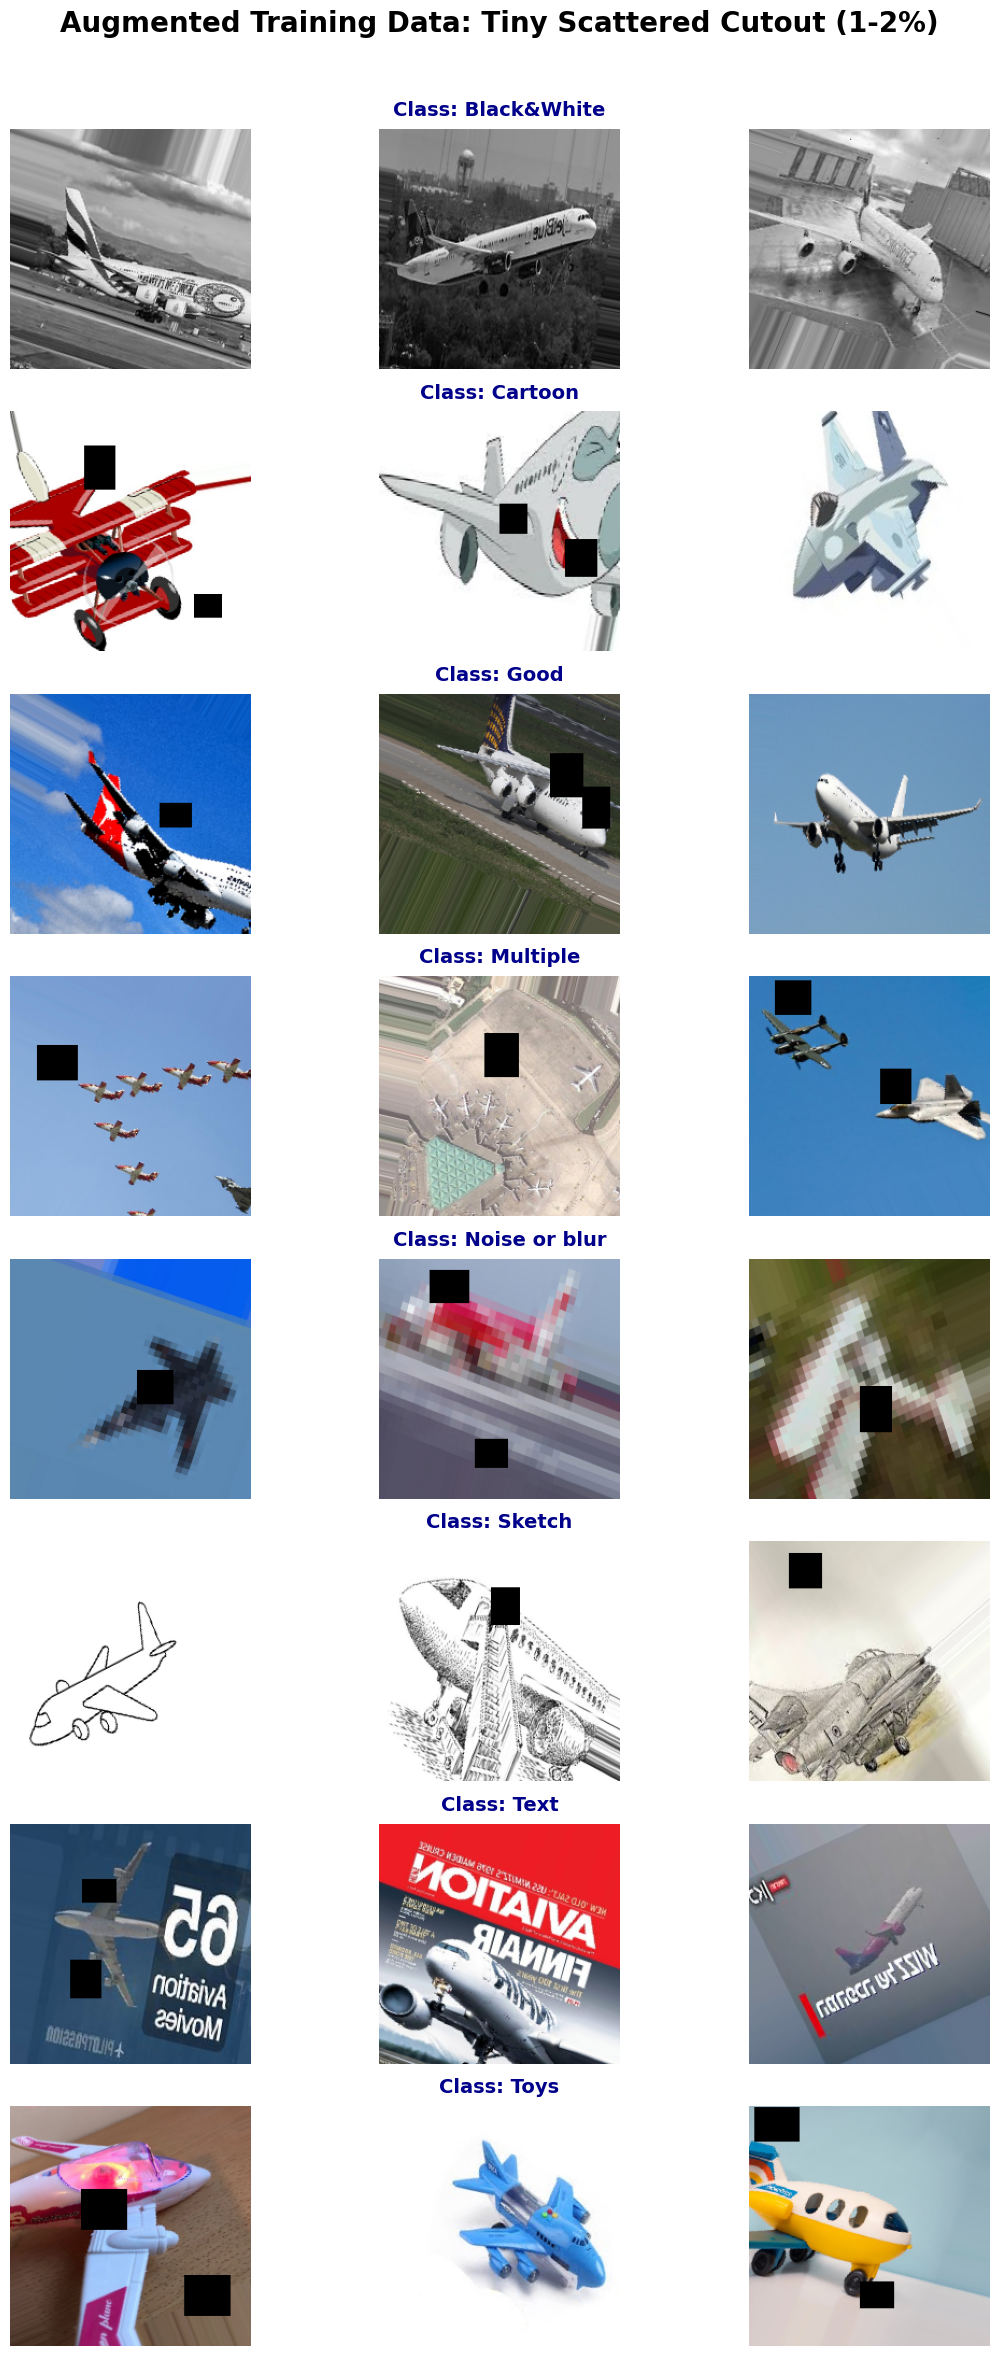

In [ ]:
print("=== הצגת דוגמאות מסט האימון (Scattered Tiny Cutout) ===")

# הגדרות לתצוגה
examples_per_class = 3
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

# מילון שיאחסן את התמונות שאספנו לכל מחלקה
collected_images = {class_name: [] for class_name in class_names}
classes_completed = 0

print("אוסף תמונות מהגנרטור (מפעיל את האוגמנטציות המזעריות בזמן אמת)...")

# ריצה על הגנרטור עד שנאסוף מספיק תמונות מכל מחלקה
for x_batch, y_batch in train_generator:
    for i in range(len(x_batch)):
        img = x_batch[i]
        label_idx = int(y_batch[i])
        class_name = class_names[label_idx]

        # אם עדיין חסרות לנו תמונות למחלקה הזו
        if len(collected_images[class_name]) < examples_per_class:
            collected_images[class_name].append(img)

            # אם הרגע סיימנו לאסוף את כל ה-3 למחלקה זו
            if len(collected_images[class_name]) == examples_per_class:
                classes_completed += 1

    # תנאי עצירה
    if classes_completed == num_classes:
        break

print("האיסוף הושלם! מכין את התצוגה...")

# --- ציור הגריד ---
fig, axes = plt.subplots(num_classes, examples_per_class, figsize=(12, 3 * num_classes))
fig.suptitle('Augmented Training Data: Tiny Scattered Cutout (1-2%)', fontsize=20, fontweight='bold', y=0.98)

for row, class_name in enumerate(class_names):
    for col in range(examples_per_class):
        ax = axes[row, col]
        img = collected_images[class_name][col]

        ax.imshow(img)
        ax.axis('off')

        if col == 1:
            ax.set_title(f"Class: {class_name}", fontsize=14, fontweight='bold', color='darkblue', pad=10)

plt.tight_layout()
plt.subplots_adjust(top=0.93)

# שמירת התמונה לשרת
plt.savefig('tiny_scattered_cutout_samples.png', dpi=300, bbox_inches='tight')
print("התמונה המעודכנת נשמרה כ- 'tiny_scattered_cutout_samples.png'")

plt.show()

# **גנרטורים**

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

print("=== הגדרת גנרטורים: Cutout מזערי ומפוזר (Numpy Pure) ===")

# --- 1. בניית פונקציית האוגמנטציה המעודכנת ---
def get_tiny_scattered_cutout(p=0.5, min_holes=5, max_holes=10, min_size=7, max_size=14):
    """
    יוצר 5-10 ריבועים מזעריים המפוזרים על התמונה, בגוון אפור אקראי.
    גישה נקייה מבוססת Numpy לקבלת שליטה מלאה בפיקסלים ללא ספריות חיצוניות.
    """
    def eraser(input_img):
        # 1. הפעלה רק ב-50% מהפעמים
        if input_img.ndim != 3 or np.random.rand() > p:
            return input_img

        img_h, img_w, _ = input_img.shape

        # 2. הגרלת כמות החורים והצבע (גוון אפור אקראי לתמונה בין שחור ללבן)
        num_holes = np.random.randint(min_holes, max_holes + 1)
        random_gray = np.random.uniform(0, 255)

        # 3. ציור הריבועים
        for _ in range(num_holes):
            h = np.random.randint(min_size, max_size + 1)
            w = np.random.randint(min_size, max_size + 1)

            x1 = np.random.randint(0, img_w - w)
            y1 = np.random.randint(0, img_h - h)

            # צביעת הריבוע בגוון האפור שנבחר
            input_img[y1:y1+h, x1:x1+w, :] = random_gray

        return input_img
    return eraser

# --- 2. שילוב באובייקט ה-ImageDataGenerator ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=get_tiny_scattered_cutout(p=0.5) # קריאה לפונקציה המזערית
)

test_val_datagen = ImageDataGenerator(rescale=1./255)

# --- 3. יצירת הגנרטורים ---
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True
)

val_generator = test_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

test_generator = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

print("\nהגנרטורים הוגדרו בהצלחה עם ה-Cutout המזערי המבוקש!")

=== הגדרת גנרטורים: Cutout מזערי ומפוזר (Numpy Pure) ===
Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.
Found 144 images belonging to 8 classes.

הגנרטורים הוגדרו בהצלחה עם ה-Cutout המזערי המבוקש!


=== הצגת דוגמאות מסט האימון (Scattered Tiny Cutout) ===
אוסף תמונות מהגנרטור (מפעיל את האוגמנטציות המזעריות בזמן אמת)...
האיסוף הושלם! מכין את התצוגה...
התמונה המעודכנת נשמרה כ- 'tiny_scattered_cutout_samples.png'


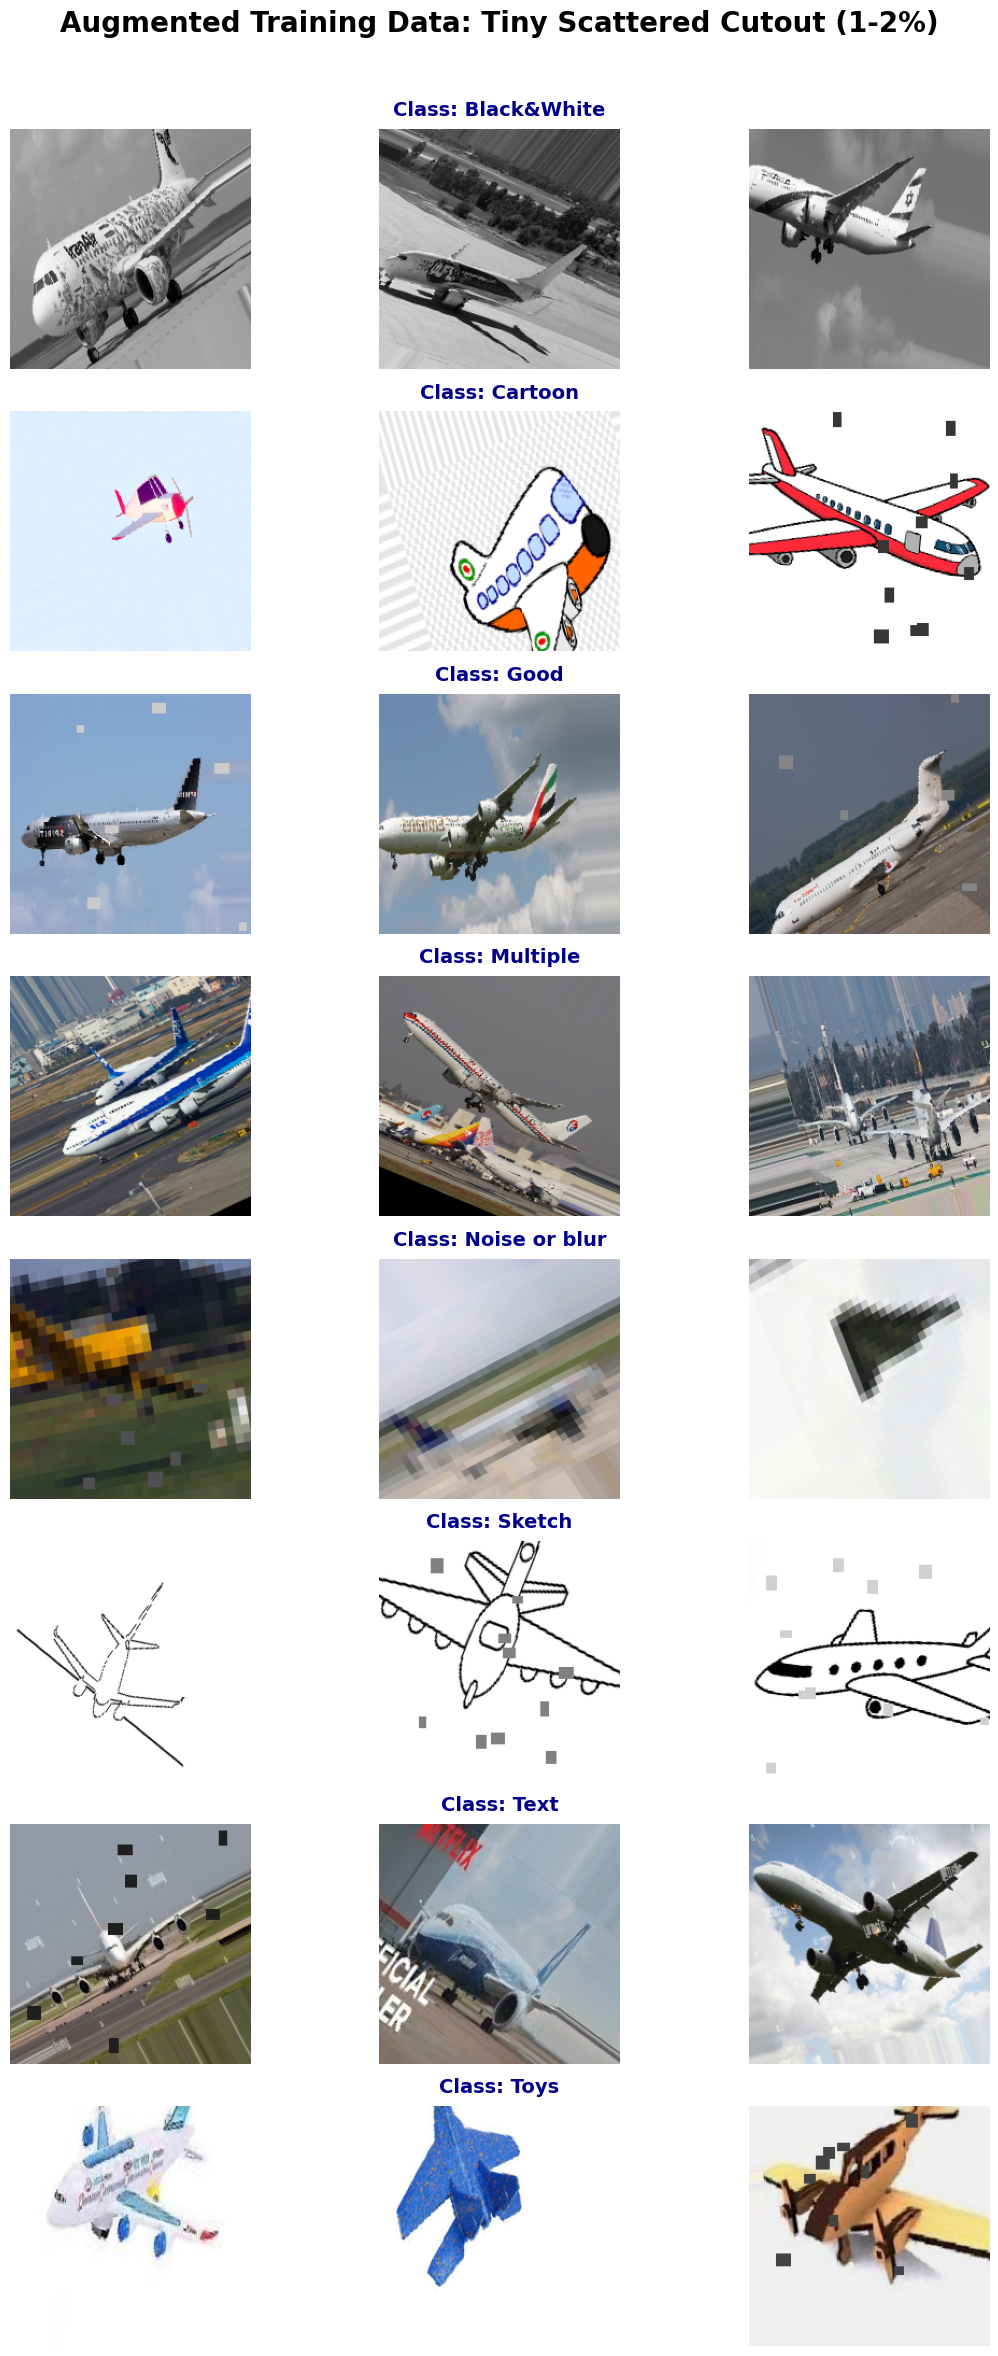

In [ ]:
print("=== הצגת דוגמאות מסט האימון (Scattered Tiny Cutout) ===")

# הגדרות לתצוגה
examples_per_class = 3
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

# מילון שיאחסן את התמונות שאספנו לכל מחלקה
collected_images = {class_name: [] for class_name in class_names}
classes_completed = 0

print("אוסף תמונות מהגנרטור (מפעיל את האוגמנטציות המזעריות בזמן אמת)...")

# ריצה על הגנרטור עד שנאסוף מספיק תמונות מכל מחלקה
for x_batch, y_batch in train_generator:
    for i in range(len(x_batch)):
        img = x_batch[i]
        label_idx = int(y_batch[i])
        class_name = class_names[label_idx]

        # אם עדיין חסרות לנו תמונות למחלקה הזו
        if len(collected_images[class_name]) < examples_per_class:
            collected_images[class_name].append(img)

            # אם הרגע סיימנו לאסוף את כל ה-3 למחלקה זו
            if len(collected_images[class_name]) == examples_per_class:
                classes_completed += 1

    # תנאי עצירה
    if classes_completed == num_classes:
        break

print("האיסוף הושלם! מכין את התצוגה...")

# --- ציור הגריד ---
fig, axes = plt.subplots(num_classes, examples_per_class, figsize=(12, 3 * num_classes))
fig.suptitle('Augmented Training Data: Tiny Scattered Cutout (1-2%)', fontsize=20, fontweight='bold', y=0.98)

for row, class_name in enumerate(class_names):
    for col in range(examples_per_class):
        ax = axes[row, col]
        img = collected_images[class_name][col]

        ax.imshow(img)
        ax.axis('off')

        if col == 1:
            ax.set_title(f"Class: {class_name}", fontsize=14, fontweight='bold', color='darkblue', pad=10)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

# **אימון המודל**

In [ ]:
# --- 1. הגדרת פרמטרים לאימון (לפי תוצאות ה-HPO) ---
EPOCHS = 50 # 25 אפוקים נוספים כדי לאפשר התכנסות בשילוב הCUTOUT
LEARNING_RATE = 0.0001
DROPOUT_RATE = 0.5
DENSE_LAYER_UNITS = 256

print(f"Starting Training with: LR={LEARNING_RATE}, Dropout={DROPOUT_RATE}, Units={DENSE_LAYER_UNITS}")

# --- 2. טעינת המודל ובניית הארכיטקטורה ---
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# טעינת VGG16 בסיסי
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-Tuning: הקפאת כל השכבות למעט בלוק 5
for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

# בניית המודל הסופי
model = models.Sequential([
    base_model,
    layers.Flatten(name='flatten'),
    layers.Dense(DENSE_LAYER_UNITS, activation='relu', name='final_dense_layer'),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(len(train_generator.class_indices), activation='softmax', name='predictions')
])

# קומפילציה
model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- 3. הגדרת Callbacks ושמירת משקולות ---
# הקובץ יישמר בשרת תחת השם: vgg16_cutout_model.h5
checkpoint_path = "vgg16_cutout_model.h5"

callbacks_list = [
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=12,             # סבלנות בגלל הקושי של ה-Cutout
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# --- 4. הרצת האימון (Fitting) ---
print("\n--- Training Process Started ---")
history = model.fit(
    train_generator,           # מתואם לשם הגנרטור שלך
    validation_data=val_generator, # מתואם לשם הגנרטור שלך
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

print(f"\nTraining finished. model saved as: {checkpoint_path}")

Starting Training with: LR=0.0001, Dropout=0.5, Units=256


2026-05-14 12:06:04.274831: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 36135 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:37:00.0, compute capability: 8.0



--- Training Process Started ---
Epoch 1/50


2026-05-14 12:06:12.395347: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2026-05-14 12:06:13.629462: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-14 12:06:15.360205: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-14 12:06:16.024861: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f9983689330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-14 12:06:16.024881: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2026-05-14 12:06:16.031748: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-14 12:06:16.190769: I ./tensorflow/compiler/jit/device_compil

21/21 [==============================] - ETA: 0s - loss: 1.9170 - accuracy: 0.2619
Epoch 1: val_accuracy improved from -inf to 0.52083, saving model to vgg16_cutout_model.h5


/users/amit.cohen/.local/lib/python3.9/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


21/21 [==============================] - 22s 536ms/step - loss: 1.9170 - accuracy: 0.2619 - val_loss: 1.2808 - val_accuracy: 0.5208 - lr: 1.0000e-04
Epoch 2/50
21/21 [==============================] - ETA: 0s - loss: 1.1767 - accuracy: 0.5625
Epoch 2: val_accuracy improved from 0.52083 to 0.75000, saving model to vgg16_cutout_model.h5
21/21 [==============================] - 10s 491ms/step - loss: 1.1767 - accuracy: 0.5625 - val_loss: 0.8064 - val_accuracy: 0.7500 - lr: 1.0000e-04
Epoch 3/50
21/21 [==============================] - ETA: 0s - loss: 0.8702 - accuracy: 0.6801
Epoch 3: val_accuracy did not improve from 0.75000
21/21 [==============================] - 9s 451ms/step - loss: 0.8702 - accuracy: 0.6801 - val_loss: 0.9016 - val_accuracy: 0.6667 - lr: 1.0000e-04
Epoch 4/50
21/21 [==============================] - ETA: 0s - loss: 0.6360 - accuracy: 0.7679
Epoch 4: val_accuracy did not improve from 0.75000
21/21 [==============================] - 10s 473ms/step - loss: 0.6360 - acc

# **ויזואליזציית נתוני אימון המודל**

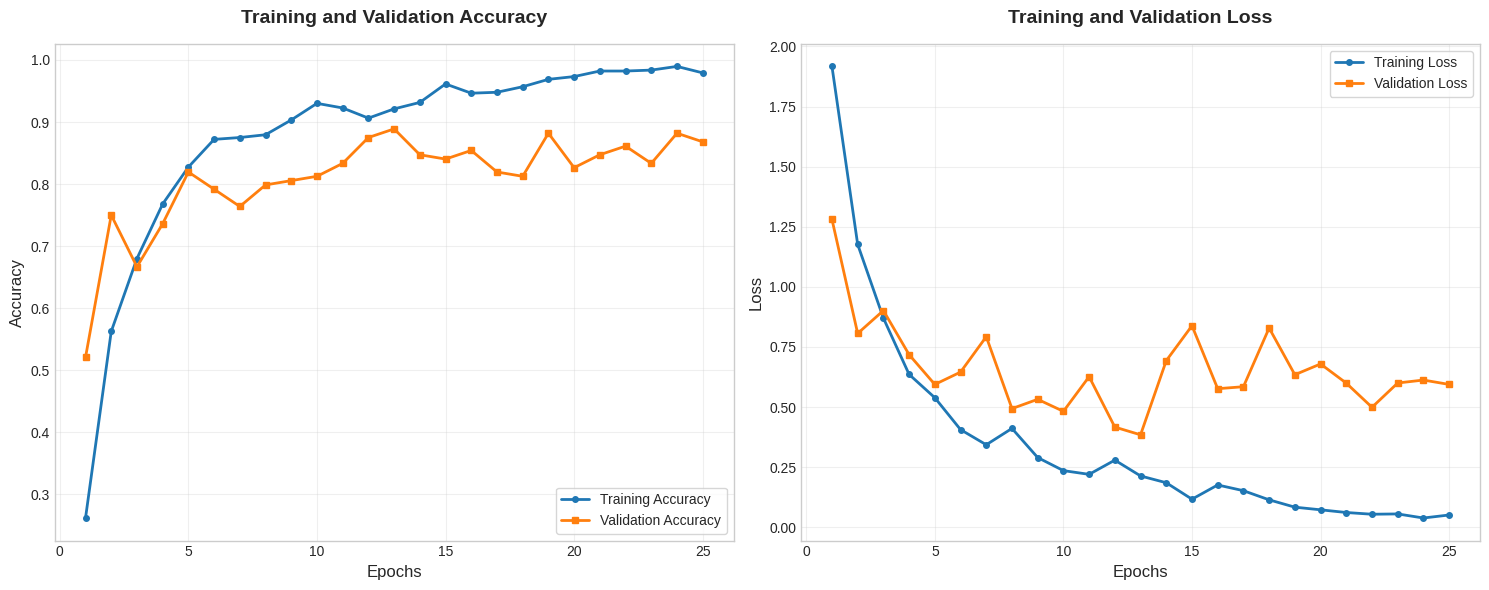

In [ ]:
# 1. חילוץ הנתונים מתוך אובייקט ה-history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# 2. הגדרת סגנון התצוגה
plt.figure(figsize=(15, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# --- גרף הדיוק (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2, marker='s', markersize=4)
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.grid(True, alpha=0.3)

# --- גרף ההפסד (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='s', markersize=4)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, alpha=0.3)

# הצגת הגרפים
plt.tight_layout()
plt.show()

# **שחזור המודל**

In [ ]:
from tensorflow.keras.models import load_model

print("טוען מודל מהתיקייה הנוכחית בשרת...")
model = load_model('vgg16_cutout_model.h5')
print("המודל נטען בהצלחה!")

טוען מודל מהתיקייה הנוכחית בשרת...


2026-06-04 13:36:54.677226: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 35345 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:37:00.0, compute capability: 8.0


המודל נטען בהצלחה!


# **תוצאות אימון**

מנתח ביצועים על סט האימון (Training Set)
Found 672 images belonging to 8 classes.

מחשב תחזיות... (זה עשוי לקחת כמה שניות)


2026-06-04 13:37:16.536743: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2026-06-04 13:37:17.131387: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


 1/21 [>.............................] - ETA: 2:48

2026-06-04 13:37:18.680988: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


21/21 [==============================] - 12s 167ms/step

דיוק המודל על סט האימון (נקי מאוגמנטציות): 98.36%

--- מפיק מטריצת בלבול ---


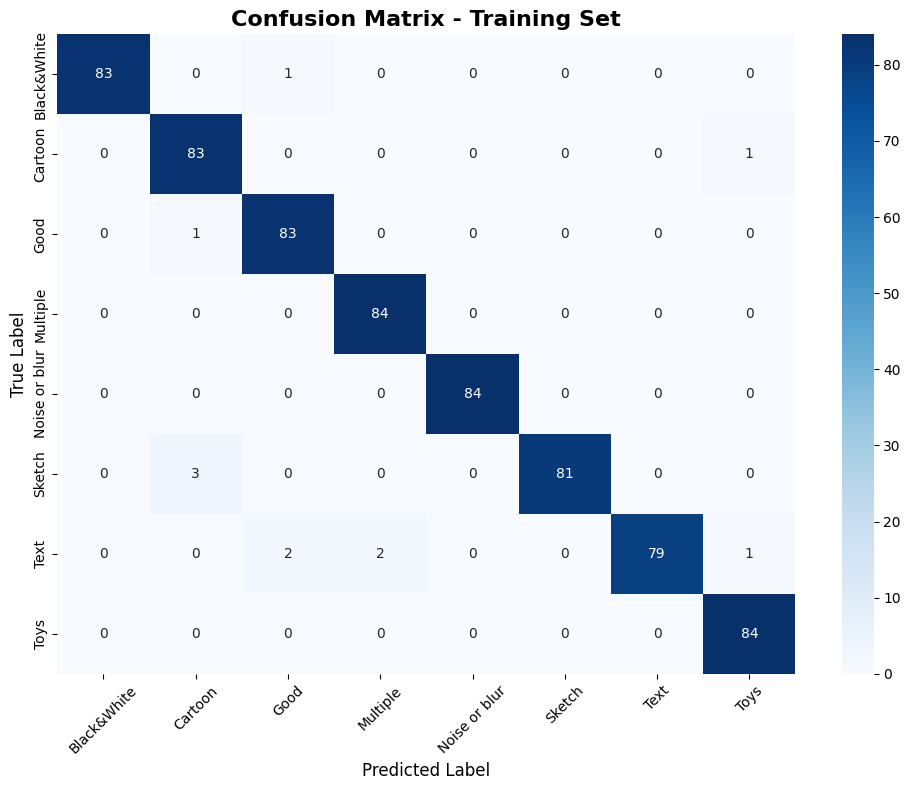


--- מציג שגיאות סיווג מובילות (Softmax Probabilities) ---
נמצאו 11 שגיאות בסך הכל בסט האימון. מציג דוגמאות בולטות (עד 5):



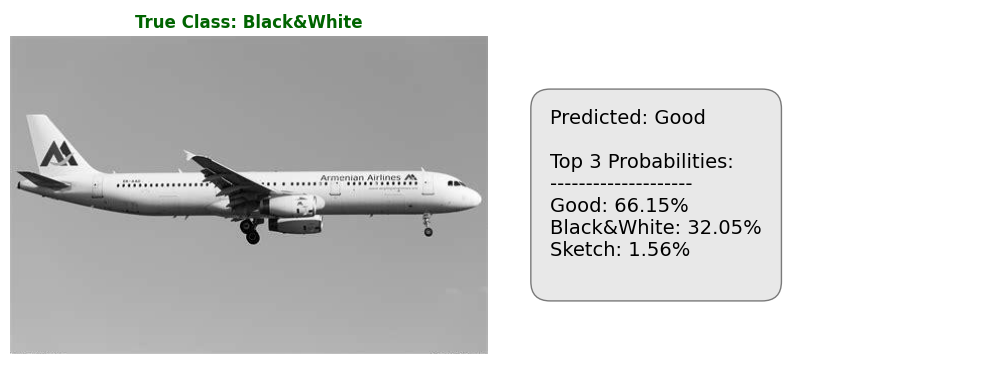

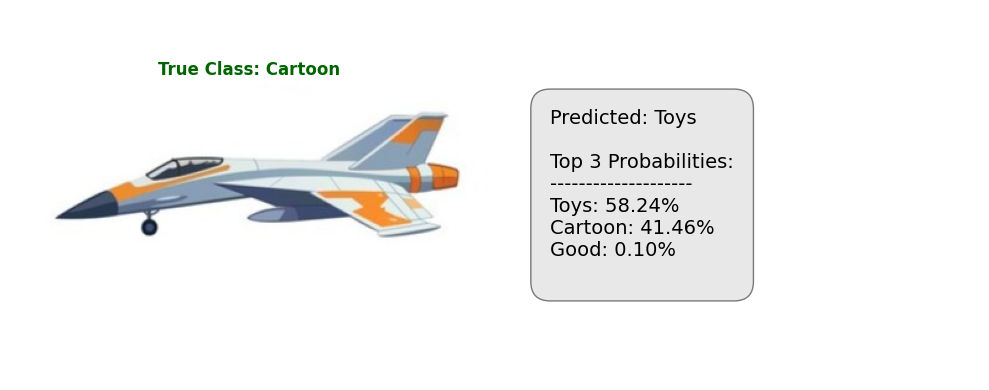

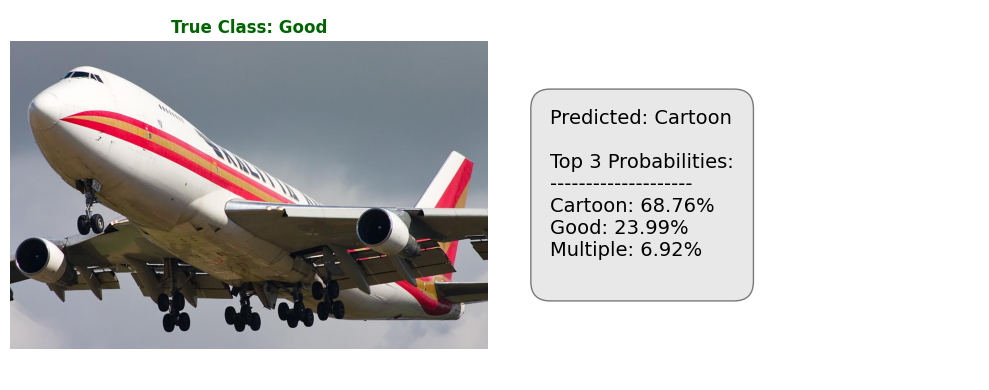

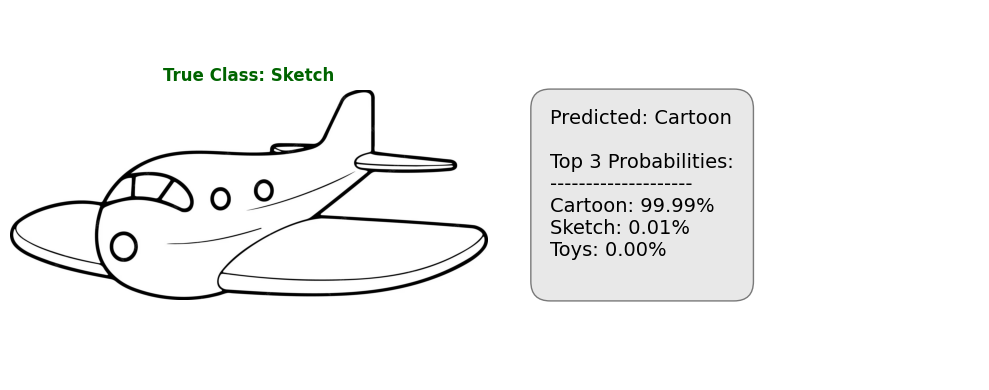

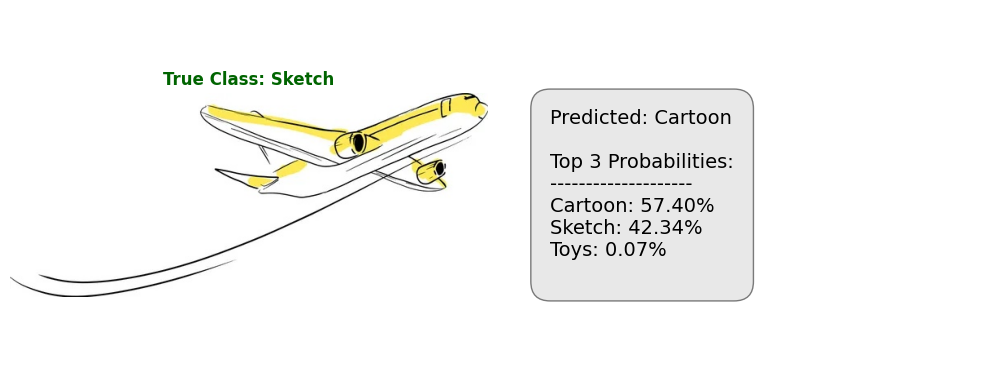

In [ ]:
print("מנתח ביצועים על סט האימון (Training Set)")

# 1. יצירת גנרטור "נקי" לאימון (חובה: ללא אוגמנטציות וללא ערבוב - shuffle=False)
eval_train_datagen = ImageDataGenerator(rescale=1./255)
eval_train_gen = eval_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

class_names = list(eval_train_gen.class_indices.keys())

# 2. ביצוע תחזיות על כל תמונות האימון
print("\nמחשב תחזיות... (זה עשוי לקחת כמה שניות)")
y_pred_probs = model.predict(eval_train_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = eval_train_gen.classes

# 3. חישוב והדפסת אחוז הדיוק הכללי
train_accuracy = np.mean(y_pred == y_true) * 100
print(f"\nדיוק המודל על סט האימון (נקי מאוגמנטציות): {train_accuracy:.2f}%\n")

# 4. יצירת מטריצת בלבול (Confusion Matrix)
print("--- מפיק מטריצת בלבול ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Training Set', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. זיהוי שגיאות והצגתן עם וקטור ה-Softmax
print("\n--- מציג שגיאות סיווג מובילות (Softmax Probabilities) ---")
errors_indices = np.where(y_pred != y_true)[0]
filenames = eval_train_gen.filenames

if len(errors_indices) == 0:
    print("מדהים! המודל הגיע ל-100% דיוק ואין שום שגיאות סיווג בסט האימון.")
else:
    print(f"נמצאו {len(errors_indices)} שגיאות בסך הכל בסט האימון. מציג דוגמאות בולטות (עד 5):\n")

    num_to_display = min(5, len(errors_indices))
    for i in range(num_to_display):
        idx = errors_indices[i]
        img_path = os.path.join(TRAIN_DIR, filenames[idx])
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        probs = y_pred_probs[idx]

        # סידור ההסתברויות מהגבוהה לנמוכה
        sorted_indices = np.argsort(probs)[::-1]

        # קריאת התמונה המקורית לתצוגה
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # יצירת חלונית תצוגה
            fig = plt.figure(figsize=(10, 4))

            # חלק ימני (או שמאלי): התמונה
            ax1 = plt.subplot(1, 2, 1)
            ax1.imshow(img)
            ax1.axis('off')
            ax1.set_title(f"True Class: {true_label}", color='darkgreen', fontweight='bold', fontsize=12)

            # חלק שני: טקסט ה-Softmax
            ax2 = plt.subplot(1, 2, 2)
            ax2.axis('off') # מסירים צירים כי זה רק טקסט

            # בניית הטקסט שיוצג
            info_text = f"Predicted: {pred_label}\n\n"
            info_text += "Top 3 Probabilities:\n"
            info_text += "-"*20 + "\n"

            # מציגים רק את 3 ההסתברויות הגבוהות ביותר כדי לא להעמיס
            for j in range(3):
                class_idx = sorted_indices[j]
                info_text += f"{class_names[class_idx]}: {probs[class_idx]*100:.2f}%\n"

            ax2.text(0.1, 0.5, info_text, fontsize=14, verticalalignment='center', bbox=dict(facecolor='lightgray', alpha=0.5, boxstyle='round,pad=1'))

            plt.tight_layout()
            plt.show()
        else:
             print(f"שגיאה: לא ניתן לטעון את התמונה מהנתיב: {img_path}")

# **תוצאות אימות**

מנתח ביצועים על סט האימות (Validation Set)
Found 144 images belonging to 8 classes.

מחשב תחזיות... (זה עשוי לקחת כמה שניות)
5/5 [==============================] - 1s 276ms/step

דיוק המודל על סט האימות: 88.89%

--- מפיק מטריצת בלבול ---


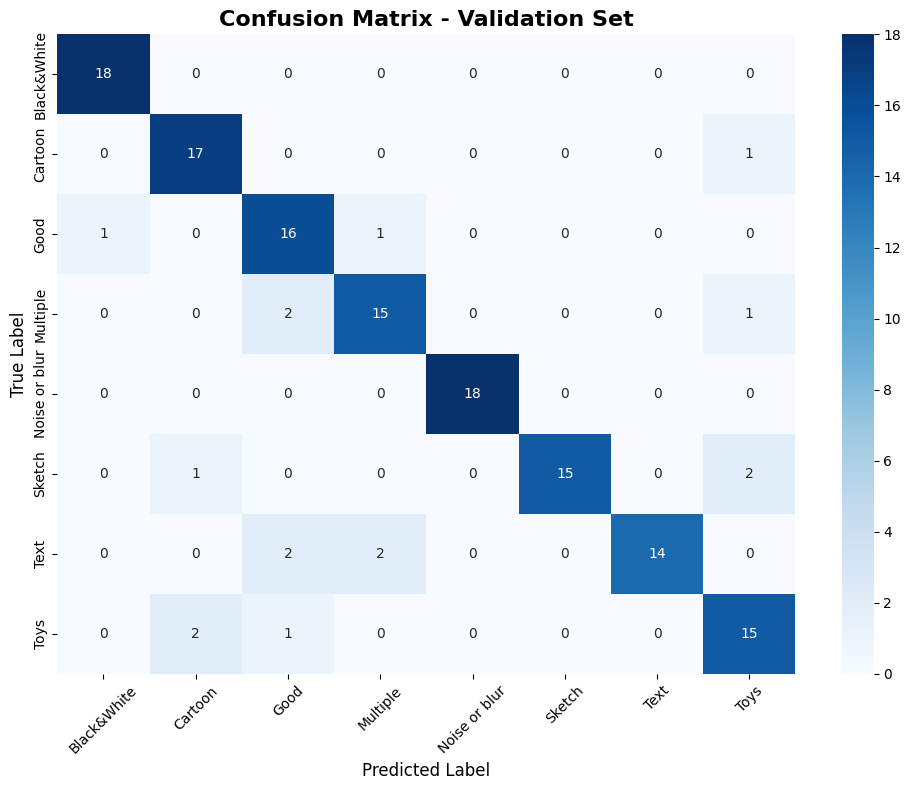


--- מציג שגיאות סיווג מובילות (Softmax Probabilities) ---
נמצאו 16 שגיאות בסך הכל בסט האימות. מציג דוגמאות בולטות (עד 5):



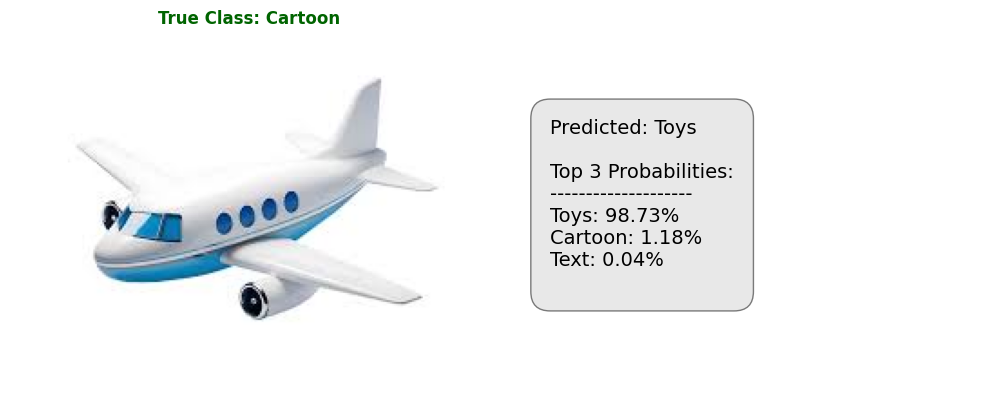

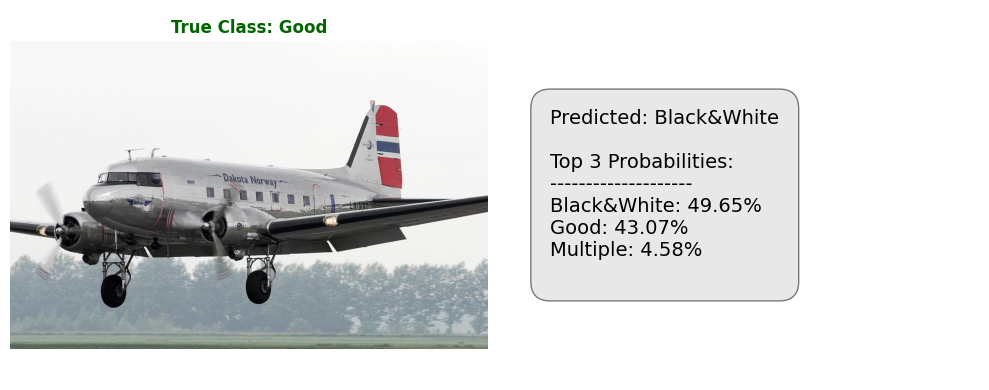

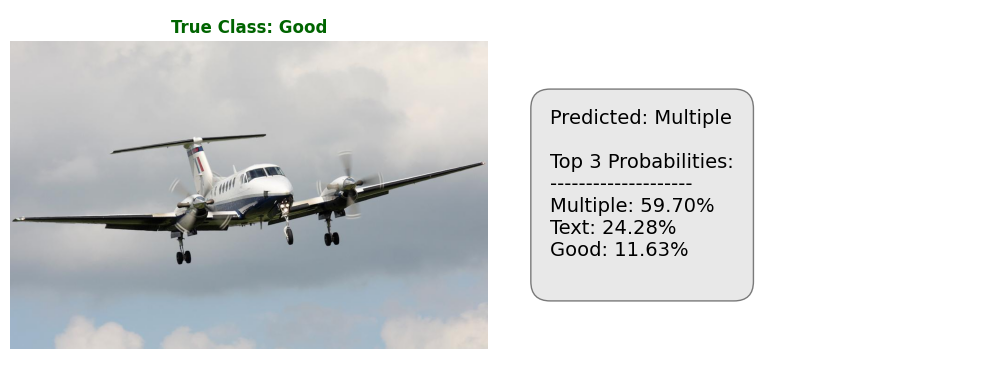

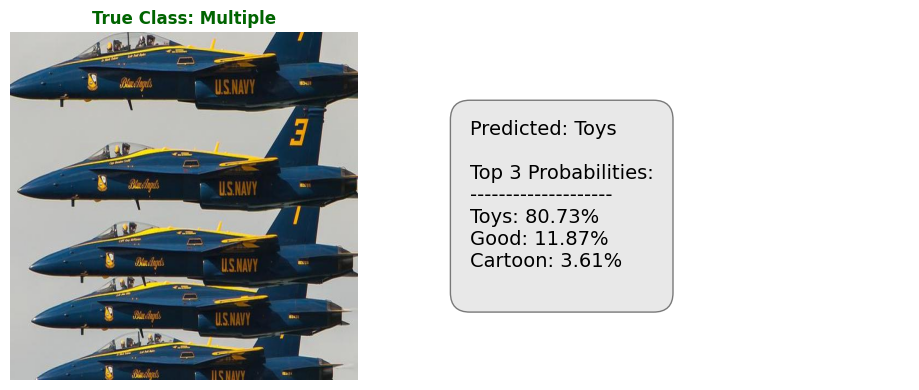

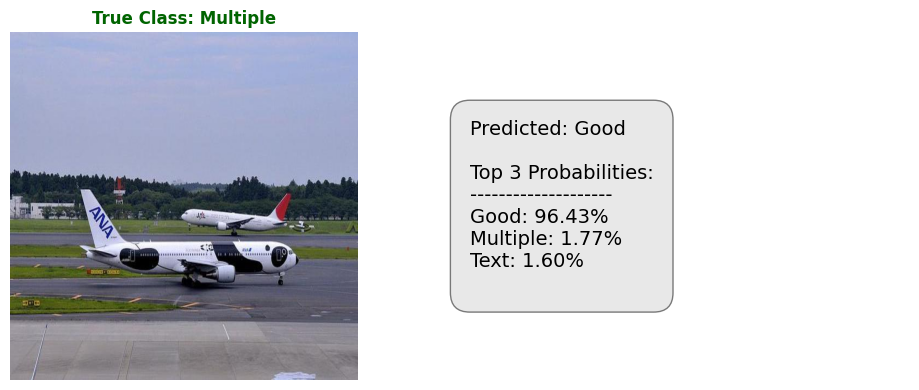

In [ ]:
print("מנתח ביצועים על סט האימות (Validation Set)")

# 1. יצירת גנרטור "נקי" לאימות (ללא ערבוב - shuffle=False)
eval_val_datagen = ImageDataGenerator(rescale=1./255)
eval_val_gen = eval_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

class_names = list(eval_val_gen.class_indices.keys())

# 2. ביצוע תחזיות על כל תמונות האימות
print("\nמחשב תחזיות... (זה עשוי לקחת כמה שניות)")
y_pred_probs = model.predict(eval_val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = eval_val_gen.classes

# 3. חישוב והדפסת אחוז הדיוק הכללי
val_accuracy = np.mean(y_pred == y_true) * 100
print(f"\nדיוק המודל על סט האימות: {val_accuracy:.2f}%\n")

# 4. יצירת מטריצת בלבול (Confusion Matrix)
print("--- מפיק מטריצת בלבול ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Validation Set', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. זיהוי שגיאות והצגתן עם וקטור ה-Softmax
print("\n--- מציג שגיאות סיווג מובילות (Softmax Probabilities) ---")
errors_indices = np.where(y_pred != y_true)[0]
filenames = eval_val_gen.filenames

if len(errors_indices) == 0:
    print("מדהים! המודל הגיע ל-100% דיוק ואין שום שגיאות סיווג בסט האימות.")
else:
    print(f"נמצאו {len(errors_indices)} שגיאות בסך הכל בסט האימות. מציג דוגמאות בולטות (עד 5):\n")

    num_to_display = min(5, len(errors_indices))
    for i in range(num_to_display):
        idx = errors_indices[i]
        img_path = os.path.join(VAL_DIR, filenames[idx]) # שונה לנתיב האימות
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        probs = y_pred_probs[idx]

        # סידור ההסתברויות מהגבוהה לנמוכה
        sorted_indices = np.argsort(probs)[::-1]

        # קריאת התמונה המקורית לתצוגה
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # יצירת חלונית תצוגה
            fig = plt.figure(figsize=(10, 4))

            # חלק ימני (או שמאלי): התמונה
            ax1 = plt.subplot(1, 2, 1)
            ax1.imshow(img)
            ax1.axis('off')
            ax1.set_title(f"True Class: {true_label}", color='darkgreen', fontweight='bold', fontsize=12)

            # חלק שני: טקסט ה-Softmax
            ax2 = plt.subplot(1, 2, 2)
            ax2.axis('off') # מסירים צירים כי זה רק טקסט

            # בניית הטקסט שיוצג
            info_text = f"Predicted: {pred_label}\n\n"
            info_text += "Top 3 Probabilities:\n"
            info_text += "-"*20 + "\n"

            # מציגים רק את 3 ההסתברויות הגבוהות ביותר כדי לא להעמיס
            for j in range(3):
                class_idx = sorted_indices[j]
                info_text += f"{class_names[class_idx]}: {probs[class_idx]*100:.2f}%\n"

            ax2.text(0.1, 0.5, info_text, fontsize=14, verticalalignment='center', bbox=dict(facecolor='lightgray', alpha=0.5, boxstyle='round,pad=1'))

            plt.tight_layout()
            plt.show()
        else:
             print(f"שגיאה: לא ניתן לטעון את התמונה מהנתיב: {img_path}")

# **מבחן**

מנתח ביצועים על סט המבחן (Test Set)
Found 144 images belonging to 8 classes.

מחשב תחזיות... (זה עשוי לקחת כמה שניות)
5/5 [==============================] - 1s 128ms/step

דיוק המודל על סט המבחן: 90.28%

--- מפיק מטריצת בלבול ---


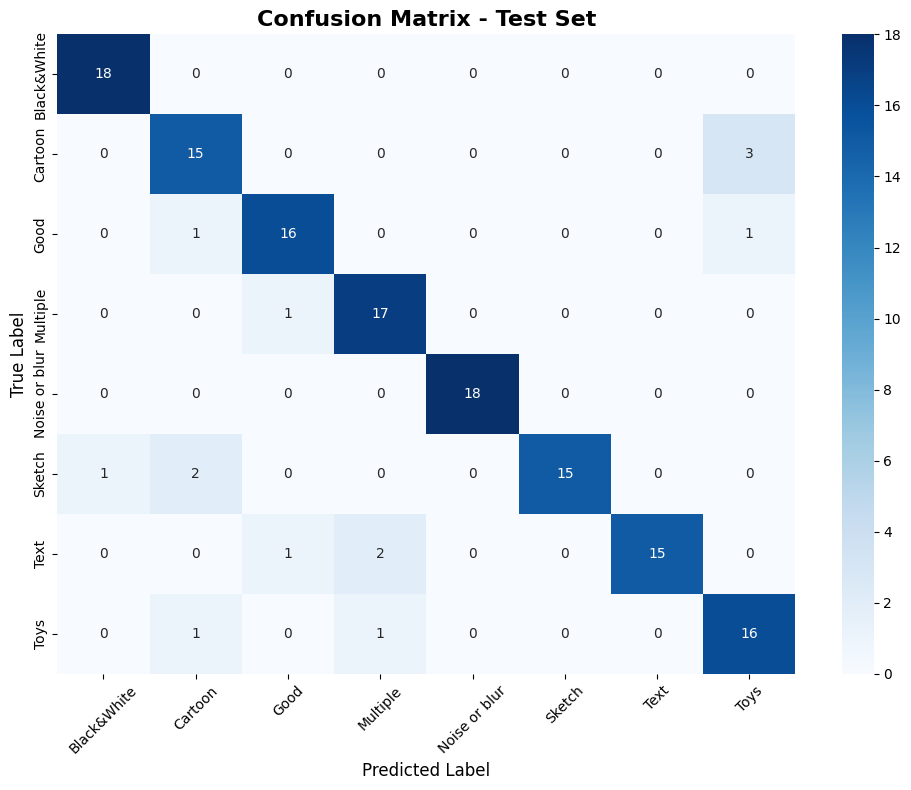


--- מציג שגיאות סיווג מובילות (Softmax Probabilities) ---
נמצאו 14 שגיאות בסך הכל בסט המבחן. מציג דוגמאות בולטות (עד 5):



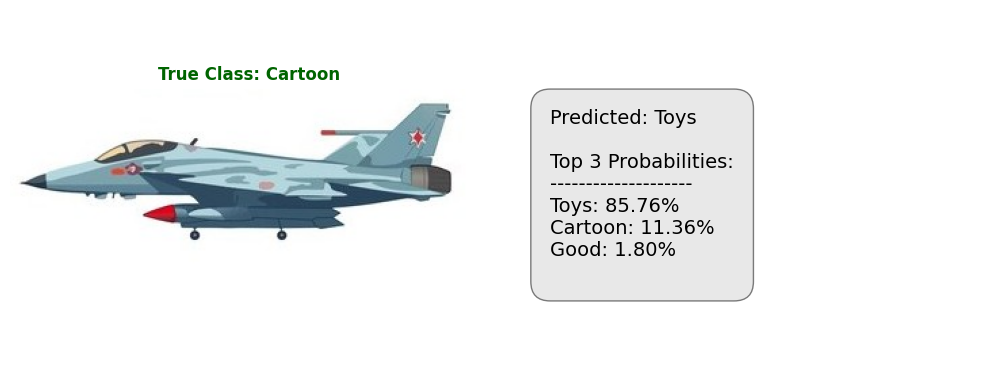

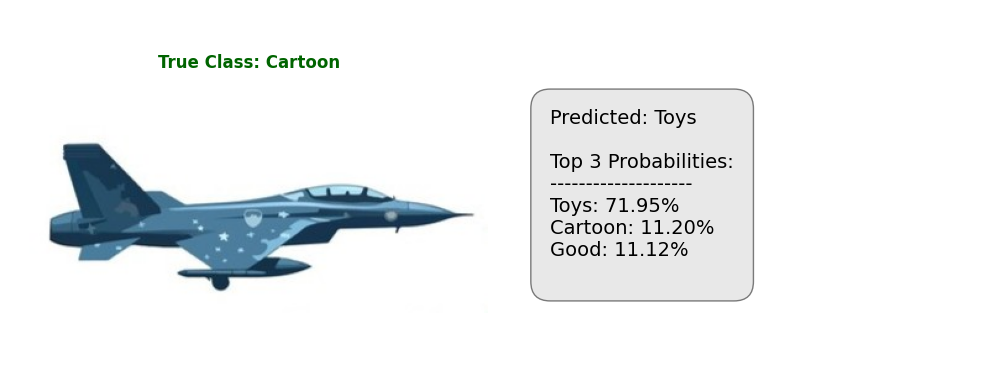

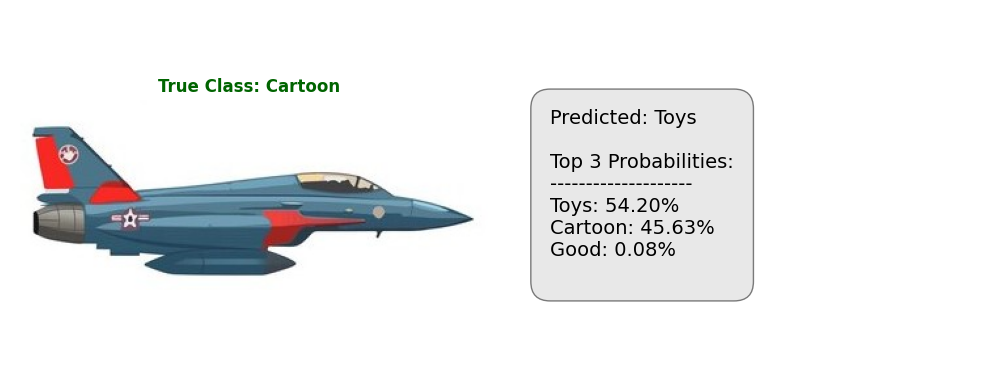

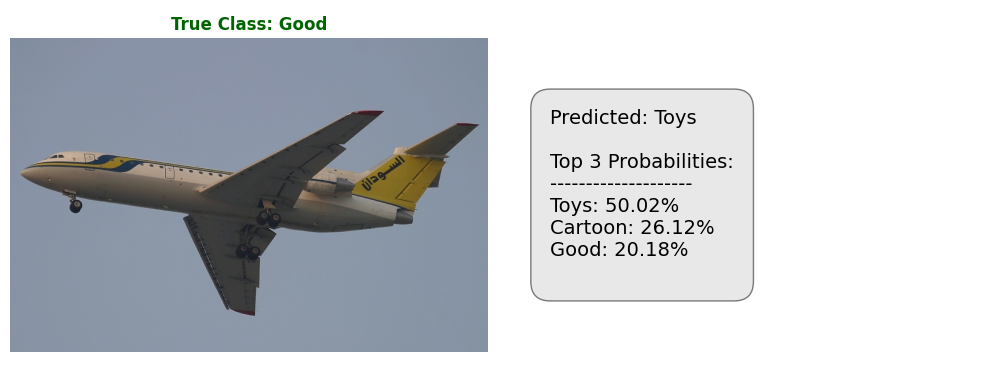

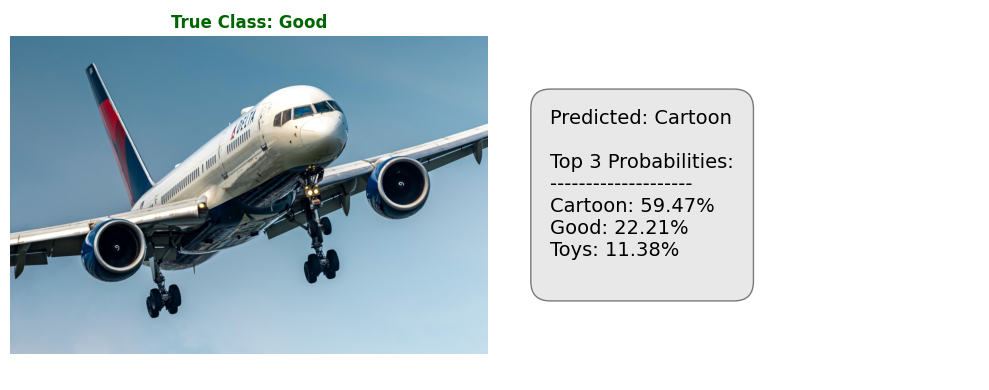

In [ ]:
print("מנתח ביצועים על סט המבחן (Test Set)")

# 1. יצירת גנרטור "נקי" למבחן (ללא ערבוב - shuffle=False)
eval_test_datagen = ImageDataGenerator(rescale=1./255)
eval_test_gen = eval_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

class_names = list(eval_test_gen.class_indices.keys())

# 2. ביצוע תחזיות על כל תמונות המבחן
print("\nמחשב תחזיות... (זה עשוי לקחת כמה שניות)")
y_pred_probs = model.predict(eval_test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = eval_test_gen.classes

# 3. חישוב והדפסת אחוז הדיוק הכללי
test_accuracy = np.mean(y_pred == y_true) * 100
print(f"\nדיוק המודל על סט המבחן: {test_accuracy:.2f}%\n")

# 4. יצירת מטריצת בלבול (Confusion Matrix)
print("--- מפיק מטריצת בלבול ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. זיהוי שגיאות והצגתן עם וקטור ה-Softmax
print("\n--- מציג שגיאות סיווג מובילות (Softmax Probabilities) ---")
errors_indices = np.where(y_pred != y_true)[0]
filenames = eval_test_gen.filenames

if len(errors_indices) == 0:
    print("מדהים! המודל הגיע ל-100% דיוק ואין שום שגיאות סיווג בסט המבחן.")
else:
    print(f"נמצאו {len(errors_indices)} שגיאות בסך הכל בסט המבחן. מציג דוגמאות בולטות (עד 5):\n")

    num_to_display = min(5, len(errors_indices))
    for i in range(num_to_display):
        idx = errors_indices[i]
        img_path = os.path.join(TEST_DIR, filenames[idx]) # שונה לנתיב המבחן
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        probs = y_pred_probs[idx]

        # סידור ההסתברויות מהגבוהה לנמוכה
        sorted_indices = np.argsort(probs)[::-1]

        # קריאת התמונה המקורית לתצוגה
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # יצירת חלונית תצוגה
            fig = plt.figure(figsize=(10, 4))

            # חלק ימני (או שמאלי): התמונה
            ax1 = plt.subplot(1, 2, 1)
            ax1.imshow(img)
            ax1.axis('off')
            ax1.set_title(f"True Class: {true_label}", color='darkgreen', fontweight='bold', fontsize=12)

            # חלק שני: טקסט ה-Softmax
            ax2 = plt.subplot(1, 2, 2)
            ax2.axis('off') # מסירים צירים כי זה רק טקסט

            # בניית הטקסט שיוצג
            info_text = f"Predicted: {pred_label}\n\n"
            info_text += "Top 3 Probabilities:\n"
            info_text += "-"*20 + "\n"

            # מציגים רק את 3 ההסתברויות הגבוהות ביותר כדי לא להעמיס
            for j in range(3):
                class_idx = sorted_indices[j]
                info_text += f"{class_names[class_idx]}: {probs[class_idx]*100:.2f}%\n"

            ax2.text(0.1, 0.5, info_text, fontsize=14, verticalalignment='center', bbox=dict(facecolor='lightgray', alpha=0.5, boxstyle='round,pad=1'))

            plt.tight_layout()
            plt.show()
        else:
             print(f"שגיאה: לא ניתן לטעון את התמונה מהנתיב: {img_path}")

# **UMAP**

/users/amit.cohen/.local/lib/python3.9/site-packages/numba/core/errors.py:194: UserWarning: Insufficiently recent colorama version found. Numba requires colorama >= 0.3.9
  warnings.warn(msg)
/users/amit.cohen/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== מתחיל ניתוח UMAP Unsupervised ===
מחלץ תכונות מסט האימון (Train)...
21/21 [==============================] - 4s 202ms/step
מחלץ תכונות מסט האימות (Val)...
5/5 [==============================] - 1s 134ms/step
מחלץ תכונות מסט המבחן (Test)...
5/5 [==============================] - 1s 129ms/step

מפעיל UMAP (Fit) על Train+Val...


/users/amit.cohen/.local/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


מטיל (Transform) את סט המבחן על גבי המרחב שלמדנו...

מצייר את הגרף...


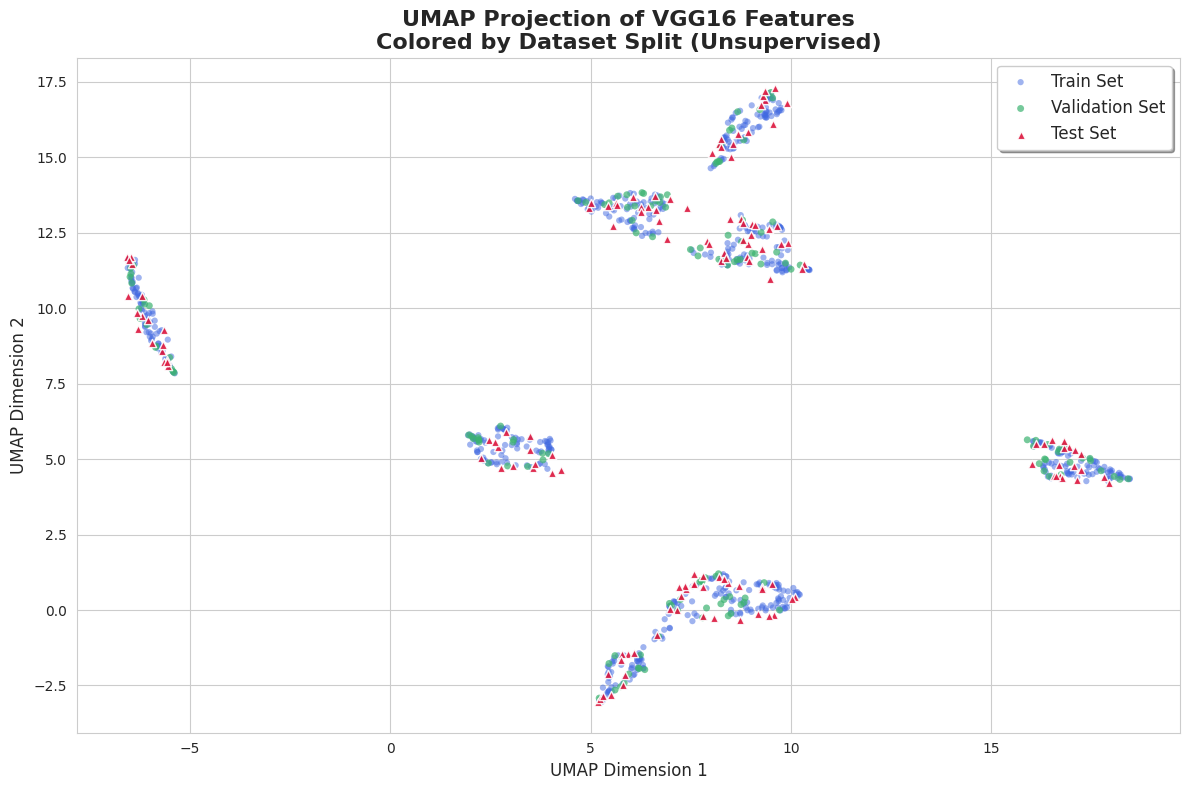

הגרף נשמר כ- 'umap_splits_projection.png'


In [ ]:
# ==========================================
# בלוק: ניתוח מרחב התכונות באמצעות Unsupervised UMAP
# (הפרדה לפי סטים: Train, Val, Test)
# ==========================================
import umap

print("=== מתחיל ניתוח UMAP Unsupervised ===")

# --- 1. יצירת "מחלץ תכונות" (Feature Extractor) ---
# אנחנו לוקחים את המודל המאומן שלנו וחותכים לו את שכבת הסיווג הסופית.
# נשתמש בשכבת final_dense_layer (256 נוירונים) שהגדרנו.
feature_extractor = Model(inputs=model.input, outputs=model.get_layer('final_dense_layer').output)

# --- 2. חילוץ התכונות מכל סט בנפרד ---
# הערה: אנו משתמשים בגנרטורים הנקיים (eval_) שיצרנו בשלבים הקודמים
# כדי שלא תהיה אוגמנטציה שתעוות את הנתונים בזמן חילוץ התכונות.
print("מחלץ תכונות מסט האימון (Train)...")
features_train = feature_extractor.predict(eval_train_gen, verbose=1)

print("מחלץ תכונות מסט האימות (Val)...")
features_val = feature_extractor.predict(eval_val_gen, verbose=1)

print("מחלץ תכונות מסט המבחן (Test)...")
features_test = feature_extractor.predict(eval_test_gen, verbose=1)

# --- 3. איחוד Train ו-Val לאימון מודל ה-UMAP ---
# מאחדים את המערכים לצורך בניית המרחב הבסיסי
features_train_val_combined = np.vstack((features_train, features_val))

# --- 4. אימון והטלה באמצעות UMAP (Unsupervised) ---
print("\nמפעיל UMAP (Fit) על Train+Val...")
# שימו לב: אין כאן העברה של ה-y (התוויות). זהו UMAP ללא הנחיה!
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding_train_val = reducer.fit_transform(features_train_val_combined)

print("מטיל (Transform) את סט המבחן על גבי המרחב שלמדנו...")
# משתמשים באובייקט ה-reducer שאומן הרגע כדי להטיל רק את ה-test
embedding_test = reducer.transform(features_test)

# פיצול התוצאות של Train ו-Val בחזרה (כדי שנוכל לצבוע אותם בנפרד בגרף)
num_train_samples = features_train.shape[0]
embedding_train = embedding_train_val[:num_train_samples]
embedding_val = embedding_train_val[num_train_samples:]

# --- 5. ויזואליזציה (צביעה לפי סט הנתונים) ---
print("\nמצייר את הגרף...")
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# ציור נקודות האימון (Train)
plt.scatter(embedding_train[:, 0], embedding_train[:, 1],
            c='royalblue', label='Train Set', alpha=0.5, s=20, edgecolor='none')

# ציור נקודות האימות (Validation)
plt.scatter(embedding_val[:, 0], embedding_val[:, 1],
            c='mediumseagreen', label='Validation Set', alpha=0.7, s=25, edgecolor='none')

# ציור נקודות המבחן (Test)
plt.scatter(embedding_test[:, 0], embedding_test[:, 1],
            c='crimson', label='Test Set', alpha=0.9, s=35, edgecolor='white', marker='^')

plt.title('UMAP Projection of VGG16 Features\nColored by Dataset Split (Unsupervised)', fontsize=16, fontweight='bold')
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)

# יצירת מקרא ברור
legend = plt.legend(loc='best', fontsize=12, frameon=True, shadow=True)
legend.get_frame().set_facecolor('white')

plt.tight_layout()
plt.savefig('umap_splits_projection.png', dpi=300)
plt.show()

print("הגרף נשמר כ- 'umap_splits_projection.png'")

# **צביעה לפי תוויות מקור**

=== מכין תצוגת UMAP לפי מחלקות ===


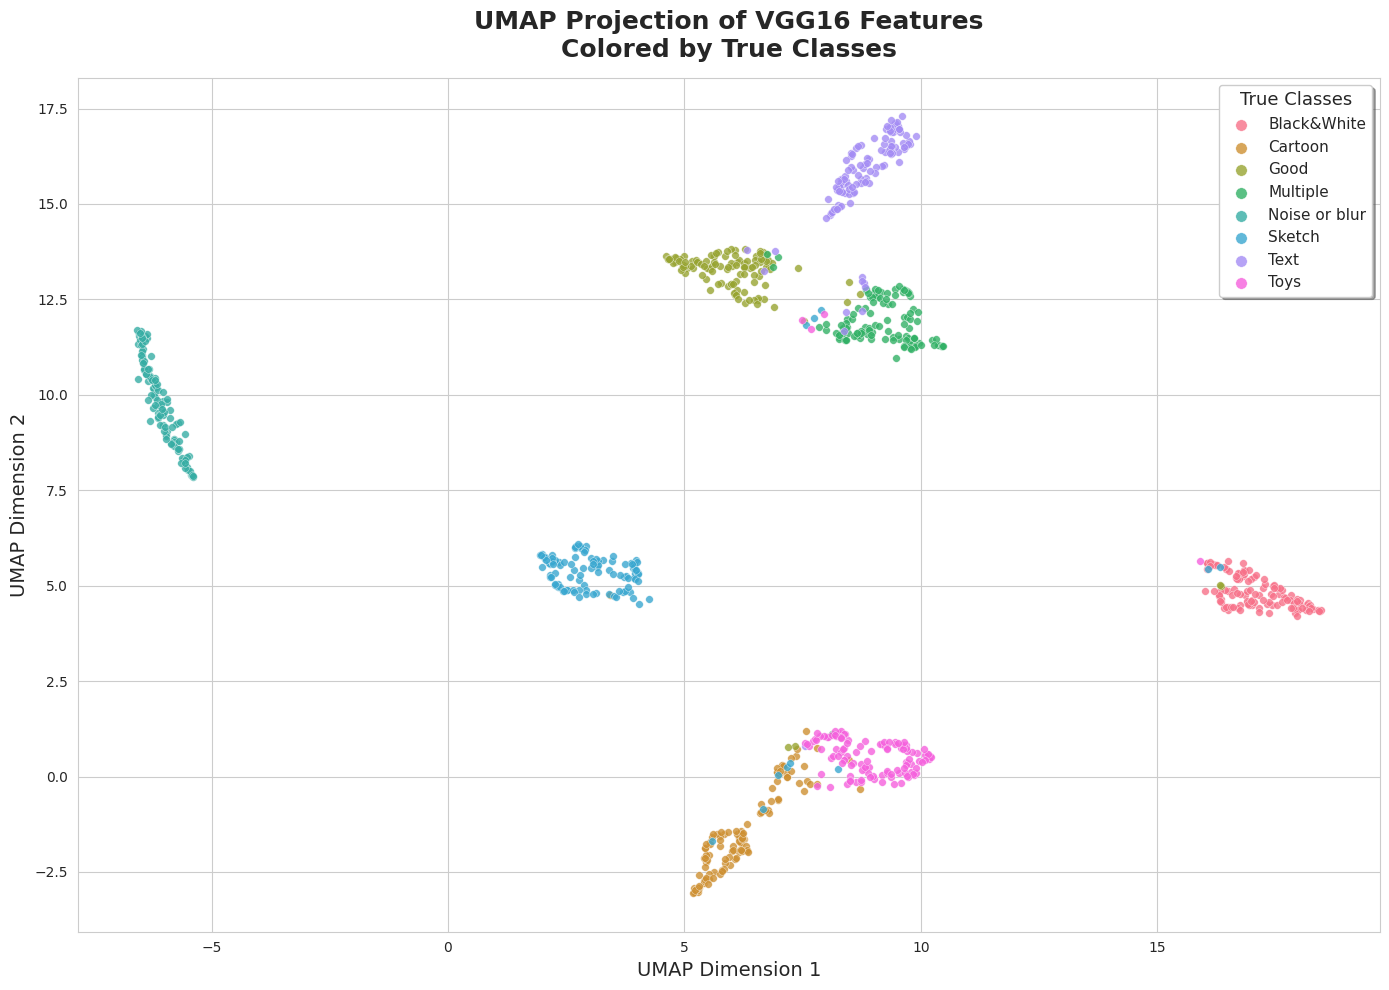

In [ ]:
# ==========================================
# בלוק: ויזואליזציה של UMAP - צביעה לפי מחלקות (True Labels)
# ==========================================
print("=== מכין תצוגת UMAP לפי מחלקות ===")

# 1. איסוף התוויות האמיתיות מכל הגנרטורים
y_train_true = eval_train_gen.classes
y_val_true = eval_val_gen.classes
y_test_true = eval_test_gen.classes

# 2. איחוד כל הקואורדינטות (מהבלוק הקודם) וכל התוויות למערך אחד גדול
all_embeddings = np.vstack((embedding_train, embedding_val, embedding_test))
all_labels = np.concatenate((y_train_true, y_val_true, y_test_true))

# 3. ציור הגרף
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

# יצירת פלטת צבעים שונה לכל מחלקה (תלוי במספר המחלקות שיש לך)
num_classes = len(class_names)
palette = sns.color_palette("husl", num_classes)

# מעבר על כל מחלקה וציור הנקודות שלה
for i, class_name in enumerate(class_names):
    # מציאת כל האינדקסים ששייכים למחלקה הנוכחית
    indices = np.where(all_labels == i)[0]

    plt.scatter(all_embeddings[indices, 0], all_embeddings[indices, 1],
                label=class_name, color=palette[i], alpha=0.8, s=30,
                edgecolor='white', linewidth=0.3)

# 4. עיצוב הגרף
plt.title('UMAP Projection of VGG16 Features\nColored by True Classes', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('UMAP Dimension 1', fontsize=14)
plt.ylabel('UMAP Dimension 2', fontsize=14)

# הוספת מקרא
legend = plt.legend(title="True Classes", title_fontsize='13', loc='best',
                    fontsize=11, frameon=True, shadow=True, markerscale=1.5)
legend.get_frame().set_facecolor('white')

plt.tight_layout()

# **הצגת הזליגות הכי "דרסטיות" מהמבחן**

=== מנתח זליגות (Anomalies) במרחב ה-UMAP עבור כל הסטים... ===

📊 סיכום זליגות (Domain Leaks) במרחב ה-UMAP 📊
סה"כ זליגות בכל הסטים (Train + Val + Test): 56
  ↳ מתוך סט האימון (Train): 20 זליגות
  ↳ מתוך סט האימות (Val): 18 זליגות
  ↳ מתוך סט המבחן (Test): 18 זליגות

🔍 מציג את ה-5 הקיצוניות ביותר מסט המבחן (כולל 3 התחזיות המובילות):



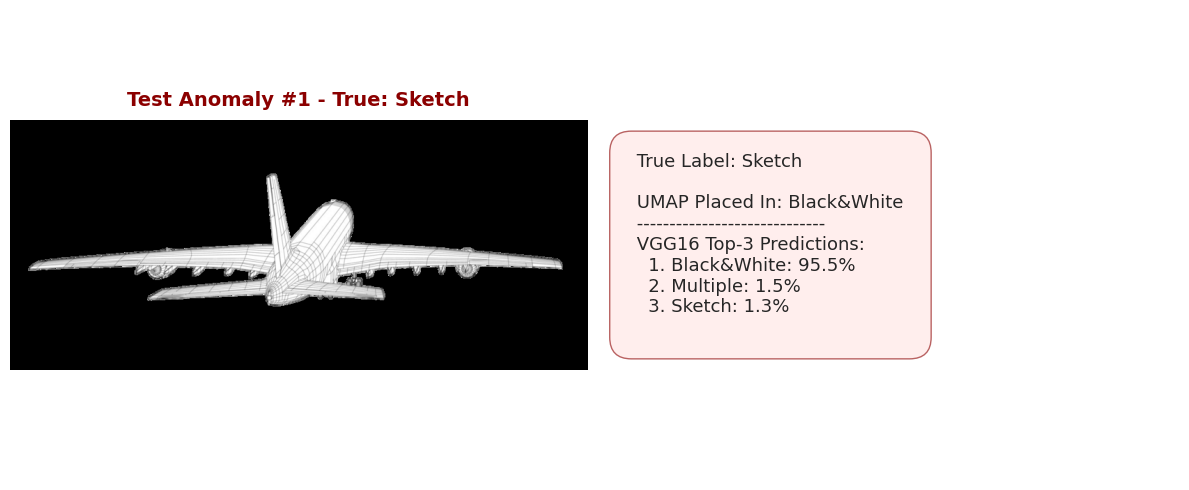

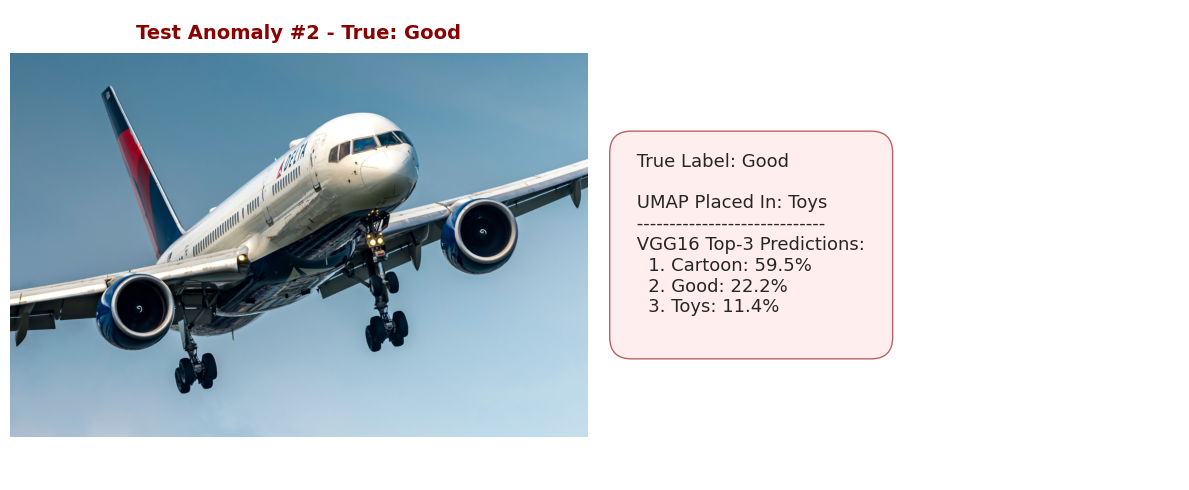

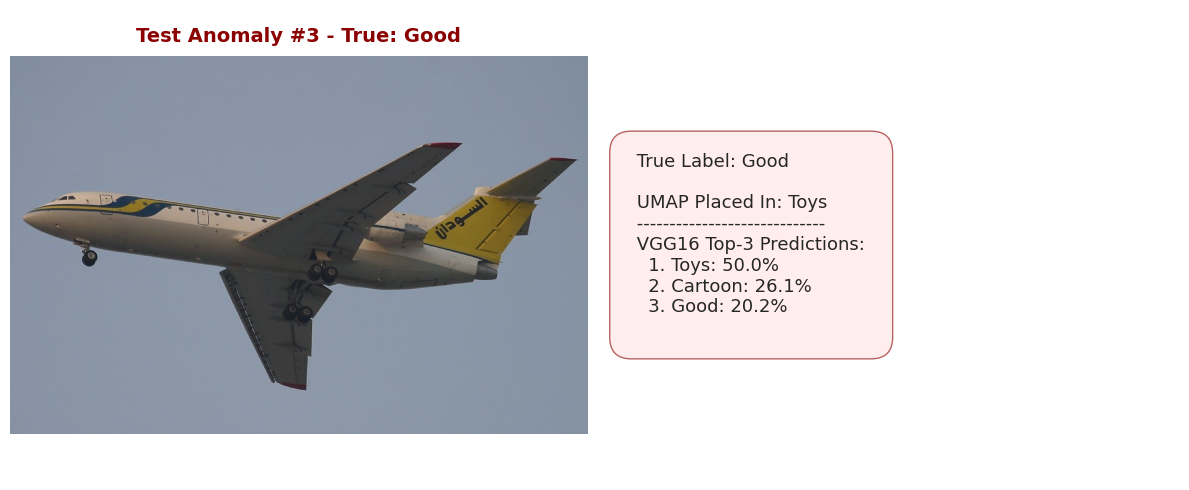

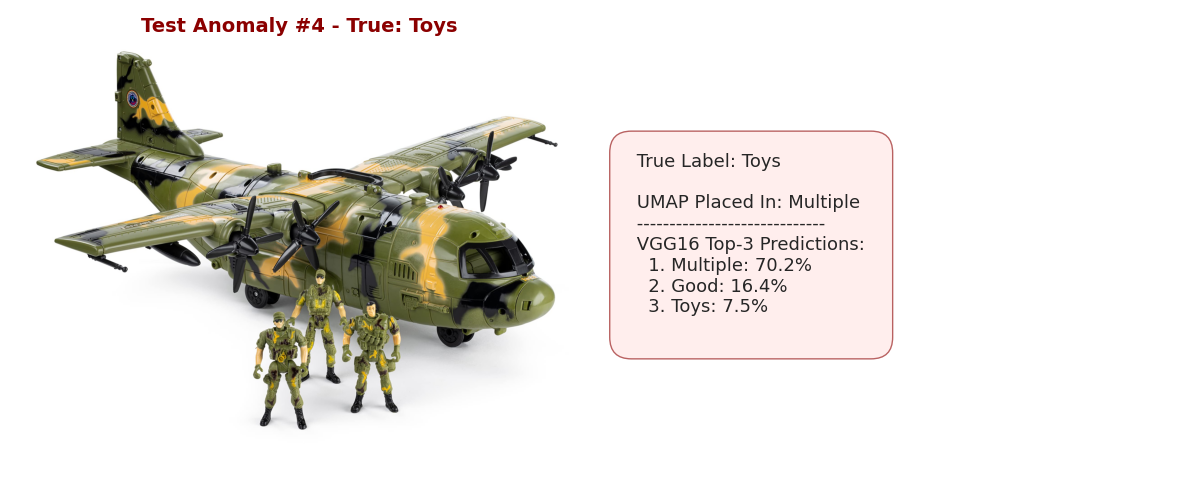

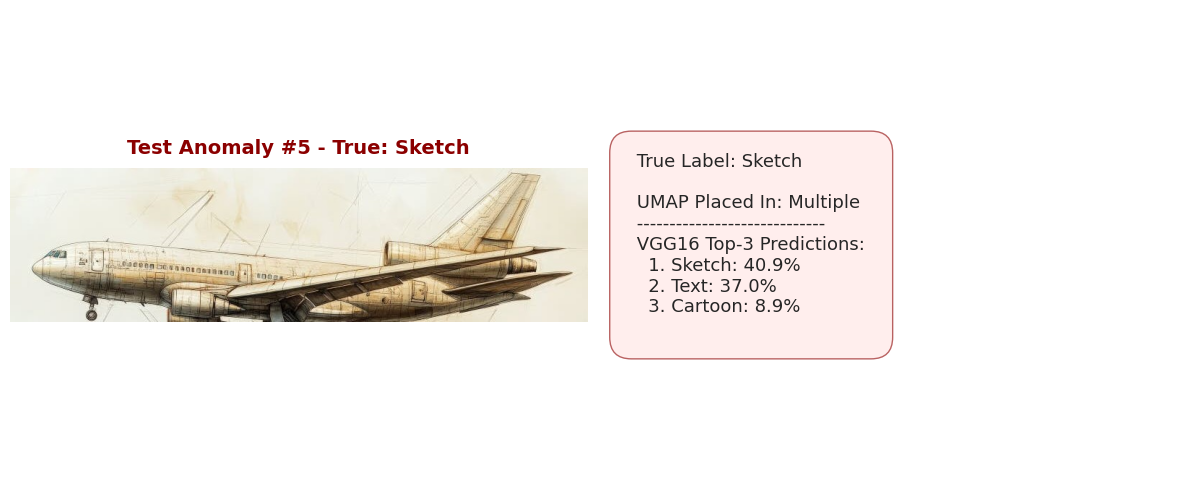

In [ ]:
# ==========================================
# בלוק: ניתוח זליגות UMAP כולל (Macro) וחקירת אנומליות מבחן (Micro) עם Top-3
# ==========================================
print("=== מנתח זליגות (Anomalies) במרחב ה-UMAP עבור כל הסטים... ===")

# 1. חישוב "מרכזי המסה" (Centroids) של המחלקות על בסיס סט האימון
centroids = {}
for i in range(len(class_names)):
    idx = np.where(y_train_true == i)[0]
    centroids[i] = np.mean(embedding_train[idx], axis=0)

# פונקציית עזר שסופרת כמה זליגות יש בסט נתון
def count_umap_leaks(embeddings, true_labels):
    leaks = 0
    for i in range(len(embeddings)):
        point = embeddings[i]
        true_class = true_labels[i]

        distances = {k: np.linalg.norm(point - v) for k, v in centroids.items()}
        closest_class = min(distances, key=distances.get)

        if closest_class != true_class:
            leaks += 1
    return leaks

# 2. ספירת זליגות בסטים השונים (אימון ואימות)
train_leaks_count = count_umap_leaks(embedding_train, y_train_true)
val_leaks_count = count_umap_leaks(embedding_val, y_val_true)

# 3. חקירה עמוקה של סט המבחן (Test Set)
test_anomalies = []
y_test_pred_probs = model.predict(eval_test_gen, verbose=0)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
test_filenames = eval_test_gen.filenames

for i in range(len(embedding_test)):
    point = embedding_test[i]
    true_class = y_test_true[i]

    dist_to_true = np.linalg.norm(point - centroids[true_class])
    distances = {k: np.linalg.norm(point - v) for k, v in centroids.items()}
    closest_umap_class = min(distances, key=distances.get)

    if closest_umap_class != true_class:
        test_anomalies.append({
            'test_index': i,
            'dist_to_true': dist_to_true,
            'true_class': true_class,
            'closest_umap': closest_umap_class,
            'vgg_pred': y_test_pred[i],
            'vgg_probs': y_test_pred_probs[i]
        })

test_leaks_count = len(test_anomalies)
total_leaks = train_leaks_count + val_leaks_count + test_leaks_count

# 4. הדפסת הסיכום הכולל (Macro View)
print("\n" + "="*60)
print("📊 סיכום זליגות (Domain Leaks) במרחב ה-UMAP 📊")
print("="*60)
print(f"סה\"כ זליגות בכל הסטים (Train + Val + Test): {total_leaks}")
print(f"  ↳ מתוך סט האימון (Train): {train_leaks_count} זליגות")
print(f"  ↳ מתוך סט האימות (Val): {val_leaks_count} זליגות")
print(f"  ↳ מתוך סט המבחן (Test): {test_leaks_count} זליגות")
print("="*60 + "\n")

# 5. הצגת 5 האנומליות הקיצוניות בסט המבחן (Micro View)
test_anomalies.sort(key=lambda x: x['dist_to_true'], reverse=True)

if test_leaks_count == 0:
    print("מדהים! לא נמצאו זליגות בסט המבחן.")
else:
    print(f"🔍 מציג את ה-5 הקיצוניות ביותר מסט המבחן (כולל 3 התחזיות המובילות):\n")

    num_to_display = min(5, test_leaks_count)
    for i in range(num_to_display):
        ano = test_anomalies[i]
        idx = ano['test_index']

        img_path = os.path.join(TEST_DIR, test_filenames[idx])
        true_label = class_names[ano['true_class']]
        umap_label = class_names[ano['closest_umap']]
        probs = ano['vgg_probs']

        # --- מציאת 3 התחזיות המובילות ---
        top_3_indices = np.argsort(probs)[::-1][:3]
        top_3_text = ""
        for rank, c_idx in enumerate(top_3_indices):
            top_3_text += f"   {rank+1}. {class_names[c_idx]}: {probs[c_idx]*100:.1f}%\n"

        # בניית הטקסט בפורמט קריא
        info_text = (
            f" True Label: {true_label} \n\n"
            f" UMAP Placed In: {umap_label} \n"
            f" ----------------------------- \n"
            f" VGG16 Top-3 Predictions: \n"
            f"{top_3_text}"
        )

        # קריאת התמונה והצגתה
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            fig = plt.figure(figsize=(12, 5))

            ax1 = plt.subplot(1, 2, 1)
            ax1.imshow(img)
            ax1.axis('off')
            ax1.set_title(f"Test Anomaly #{i+1} - True: {true_label}", color='darkred', fontweight='bold', fontsize=14, pad=10)

            ax2 = plt.subplot(1, 2, 2)
            ax2.axis('off')
            ax2.text(0.05, 0.5, info_text, fontsize=13, verticalalignment='center',
                     bbox=dict(facecolor='mistyrose', alpha=0.6, boxstyle='round,pad=1.2', edgecolor='darkred'))

            plt.tight_layout()
            plt.show()